# Comparing Models to Models using BayesCompare

This tutorial will show how to use `measure_dist` and `measure_dist_parallel` functions of `BayesCompare` to compare two neural network models. It will walk you through extracting covariances from the models, computing distances between layers and finally visualzing these results.

We use `measure_dist` function to compute a distance matrix from the given covariance matrices, in-memory, while we prefer `measure_dist_parallel` for large-scale parallel computation that writes the results to an HDF5 file on the disk. Both functions accept covariance matrices in NumPy or PyTorch format and support several distance/divergence measures within BayesCompare and other existing methods in the literature.

Imports, helper functions and pretrained models used by these two functions are the same in this tutorial. However, the main difference between the two functions is that, `measure_dist` computes the distances from in-memory covariance matrices and gives out results also in-memory. On the other hand, `measure_dist_parallel` reads from saved covariance files on the disk and saves the distance matrix to the disk. Therefore, sections related to covariance computations and distance computations are not shared.

##### Imports

In [1]:
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import h5py

import torchvision.models as models
from torchvision import datasets, transforms

from BayesCompare import measure_dist, measure_dist_parallel
from BayesCompare import cov_extractor, get_layer_names

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)
torch_gen = torch.Generator()
torch_gen.manual_seed(SEED)

##### Helper Functions

In [2]:
def get_selected_layers(model_name, all_layers):
    """ Function for getting the layer names of the last ReLU layer of ResNet18 and 
    the first layer normalization layer of ViT-B/16."""
    selected_layer_names = []
    
    if model_name == "resnet":
        for layer_idx, layer_name in enumerate(all_layers):
            # we are interested in the last ReLU layer
            if "relu" in layer_name:
                # the last ReLU layer comes after the add layer in each block
                if "add" in all_layers[layer_idx-1]:
                    selected_layer_names.append(layer_name)
                
    elif model_name == "vit":
        for layer_idx, layer_name in enumerate(all_layers):
            # we are interested in the first layer normalization layer
            if "layernorm" in layer_name:
                # fist layernorm comes after an add layer and is followed by an attention head
                if (
                    "add" in all_layers[layer_idx - 1]
                    and "attention" in all_layers[layer_idx + 1]
                ):
                    selected_layer_names.append(layer_name)
    
    return selected_layer_names

def display_inputs(dataset, num_ims_to_display: int = 5):
    fig, axes = plt.subplots(1, num_ims_to_display, figsize=(15, 3))

    for i in range(num_ims_to_display):
        img, label = dataset[i] 
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {label}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
    
def normalize_to_minus1_1(matrix):
    matrix = np.asarray(matrix)

    min_val = matrix.min()
    max_val = matrix.max()

    if max_val == min_val:
        raise ValueError("Cannot normalize: all values in the matrix are the same.")

    normalized = 2 * (matrix - min_val) / (max_val - min_val) - 1
    return normalized

def display_normalized_covs(selected_covs, layers_names):
    normalized_selected_covs = [normalize_to_minus1_1(mtx) for mtx in selected_covs]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

    for ax, mat, name in zip(axes, normalized_selected_covs, layers_names):
        im = ax.imshow(
            mat,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            interpolation="nearest",
        )
        ax.set_title(name)
        ax.axis("off")

    # One shared colorbar for all 4 plots
    cbar = fig.colorbar(im, ax=axes, shrink=0.85)
    cbar.set_label("Normalized value")

    plt.show()

def display_distance_matrices(dist_dict, layer_list):
    n_names = len(layer_list)
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(22, 5),
        constrained_layout=True,
    )

    for i, (mtx_name, mtx) in enumerate(dist_dict.items()):
        ax = axes[i]

        # Convert to NumPy in case input is a torch tensor or similar
        if hasattr(mtx, "detach"):
            mtx = mtx.detach().cpu().numpy()
        else:
            mtx = np.asarray(mtx)
        
        if "rsa" in mtx_name or "cka" in mtx_name or "RSA" in mtx_name or "CKA" in mtx_name:
            mtx = 1 - mtx
            np.fill_diagonal(mtx, 0.0)
            
        im = ax.imshow(
            mtx,
            cmap="bone",
            vmin=0,
            vmax=mtx.max(),
            interpolation="nearest",
            aspect="equal",
        )
        ax.set_title(mtx_name)
        ax.set_xticks(np.arange(n_names))
        ax.set_xticklabels(layer_list, rotation=90, fontsize=8)
        ax.set_yticks(np.arange(n_names))

        if i == 0:
            ax.set_yticklabels(layer_list, fontsize=8)
        else:
            ax.set_yticklabels([])

        ax.tick_params(axis="both", length=0)

        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )
        cbar.ax.tick_params(labelsize=8)

    plt.show()

##### Load the Pretrained Models

We will compare two ImageNet-1k trained models: ResNet18 and ViT-B/16, both loaded from TorchVision.

In [3]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print("ResNet18 model is loaded as model_resnet.")

model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
print("ViT-B/16 model is loaded as model_vit.")

ResNet18 model is loaded as model_resnet.
ViT-B/16 model is loaded as model_vit.


## 1. Inspecting available layer names and defining the wanted layers

To decide or locate the layers we are interested in from these models, we will inspect the layers of these models using the `get_layer_names` function. `BayesCompare` use `TorchLens` for activation/covariance extraction (required for the distance calculation/model comparison) under the hood. Therefore, layer naming conventions are based on `TorchLens` naming. Please refer to [TorchLens Repo](https://github.com/johnmarktaylor91/torchlens) for more details.


In [4]:
all_layer_names_resnet = get_layer_names(model_resnet)

print("ResNet18 Layers:")
for name in all_layer_names_resnet[:5]:
    print(f"{name:40s}")
print("...")    
for name in all_layer_names_resnet[-5:]:
    print(f"{name:40s}")
    
all_layer_names_vit = get_layer_names(model_vit)

print("\n---------------------------")

print("\nViT-B/16 Layers:")
for name in all_layer_names_vit[:5]:
    print(f"{name:40s}")
print("...")    
for name in  all_layer_names_vit[-5:]:
    print(f"{name:40s}")

/home/sezan/miniconda3/envs/BayesPublish11/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


ResNet18 Layers:
input_1                                 
conv2d_1_1                              
buffer_1                                
buffer_2                                
batchnorm_1_2                           
...
relu_17_66                              
adaptiveavgpool2d_1_67                  
flatten_1_68                            
linear_1_69                             
output_1                                

---------------------------

ViT-B/16 Layers:
input_1                                 
conv2d_1_1                              
reshape_1_2                             
permute_1_3                             
expand_1_4                              
...
add_25_139                              
layernorm_25_140                        
getitem_1_141                           
linear_25_142                           
output_1                                


There are a lot of layers in these networks and we are not interested in all of them. Therefore, we will get a selection of these layers as our "wanted layers". In this tutorial we are insterested in the outputs of the last ReLU of every residual block in ResNet18 and we would like to compare those to the first layer normalization layer in every block of ViT-B/16. For getting the names of these specific layers, we included a small helper function `get_selected_layers` defined above. You may use or modify this function for your needs. 

It is very helpful to check out the graph of the overall architecture at hand using the `TorchLens` functions for writing the code for selecting certain layers.

In [5]:
selected_layers_resnet = get_selected_layers(model_name="resnet", all_layers=all_layer_names_resnet)
print(f"Last ReLU layers of ResNet18 are named {selected_layers_resnet}")

selected_layers_vit = get_selected_layers(model_name="vit", all_layers=all_layer_names_vit)
print(f"First LayerNorm layers of ViT-B/16 are named {selected_layers_vit}")

Last ReLU layers of ResNet18 are named ['relu_3_11', 'relu_5_18', 'relu_7_27', 'relu_9_34', 'relu_11_43', 'relu_13_50', 'relu_15_59', 'relu_17_66']
First LayerNorm layers of ViT-B/16 are named ['layernorm_3_19', 'layernorm_5_30', 'layernorm_7_41', 'layernorm_9_52', 'layernorm_11_63', 'layernorm_13_74', 'layernorm_15_85', 'layernorm_17_96', 'layernorm_19_107', 'layernorm_21_118', 'layernorm_23_129']


## 2. Loading input images

We use Caltech-101 dataset for extracting the covariances. As we will be computing the distances between our model layers, selecting a large enough subset from the overall dataset is sufficient for our purposes. Hence, we use randomly selected 200 images from this dataset, Then, we apply transformations to these images required by our models. We take a look at a few samples form the input set,using the helper function `display_inputs`.

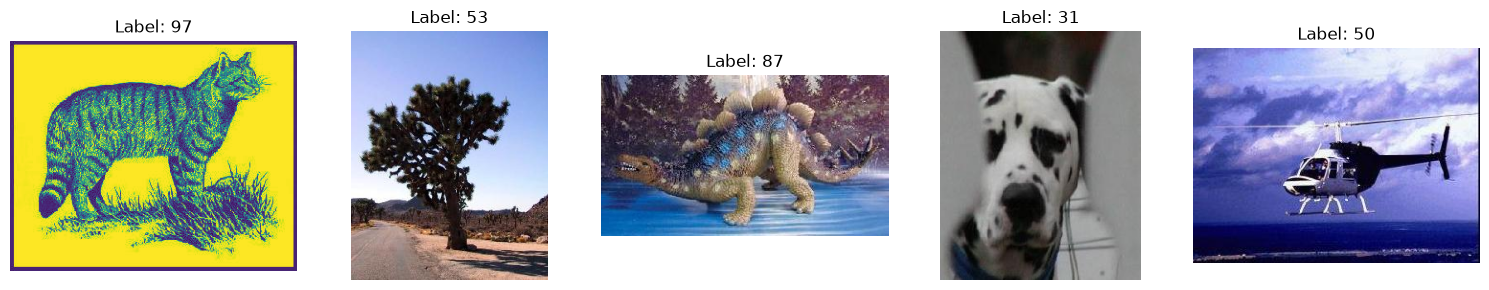

Let's check the properties of our inputs:
Input shape : torch.Size([200, 3, 224, 224])
dtype       : torch.float32
value range : [-2.118, 2.640]


In [6]:
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])
full_dataset = datasets.Caltech101(
    root="./data",
    target_type="category",
    # transform=transform,
    download=True,
)

indices = torch.randperm(len(full_dataset), generator=torch_gen)[:200]
raw_input_images = [full_dataset[i] for i in indices]

display_inputs(dataset=raw_input_images, num_ims_to_display=5)

transformed_input_images = [(transform(img), label) for img, label in raw_input_images]
images, labels = zip(*transformed_input_images)
input_images = torch.stack(images)

print("Let's check the properties of our inputs:")
print(f"Input shape : {input_images.shape}")
print(f"dtype       : {input_images[0].dtype}")
print(f"value range : [{input_images.min():.3f}, {input_images.max():.3f}]")


## 3.1 `measure_dist` Sections

### 3.1.1 Extracting covariances with `cov_extractor`

We got out models and loaded our input images. The next step is to compute covariances (second moment matrices) for each of our layers. For this, we use `cov_extractor` of `BayesCompare`. This function yields a dictionary where the keys are the layer names and the values are the corresponding covariance matrices.

In [7]:
covs_resnet = cov_extractor(
    model_resnet,
    input_images,
    selected_layers_resnet,
)

print("ResNet18 Covariances:")
for name, cov in covs_resnet.items():
    print(f"{name:30s}  shape: {tuple(cov.shape)}")
    
covs_vit = cov_extractor(
    model_vit,
    input_images,
    selected_layers_vit,
)

print("\nViT-B/16 Covariances:")
for name, cov in covs_vit.items():
    print(f"{name:30s}  shape: {tuple(cov.shape)}")

ResNet18 Covariances:
relu_3_11                       shape: (200, 200)
relu_5_18                       shape: (200, 200)
relu_7_27                       shape: (200, 200)
relu_9_34                       shape: (200, 200)
relu_11_43                      shape: (200, 200)
relu_13_50                      shape: (200, 200)
relu_15_59                      shape: (200, 200)
relu_17_66                      shape: (200, 200)

ViT-B/16 Covariances:
layernorm_3_19                  shape: (200, 200)
layernorm_5_30                  shape: (200, 200)
layernorm_7_41                  shape: (200, 200)
layernorm_9_52                  shape: (200, 200)
layernorm_11_63                 shape: (200, 200)
layernorm_13_74                 shape: (200, 200)
layernorm_15_85                 shape: (200, 200)
layernorm_17_96                 shape: (200, 200)
layernorm_19_107                shape: (200, 200)
layernorm_21_118                shape: (200, 200)
layernorm_23_129                shape: (200, 200)


We now have the covariances from two models in separate variables, however, we need to have them merged as we would like to compute the distances between all pairs of layers. In other words, to have a distance matrix of shape `(19x19)` (total number of layers x total number of layers), we need to have all 19 covariance matrices in an ordered list. Hence, we are merging these matrices.

In [8]:
all_covs = []
all_layer_names = []
for keys, values in covs_resnet.items():
    all_covs.append(values)
    all_layer_names.append(keys)
for keys, values in covs_vit.items():
    all_covs.append(values)
    all_layer_names.append(keys)

print(len(all_covs))
print(all_covs[0].shape)

19
torch.Size([200, 200])


Let's see how does our covariance matrices look like. We are choosing the first and last layers from both models to display. 

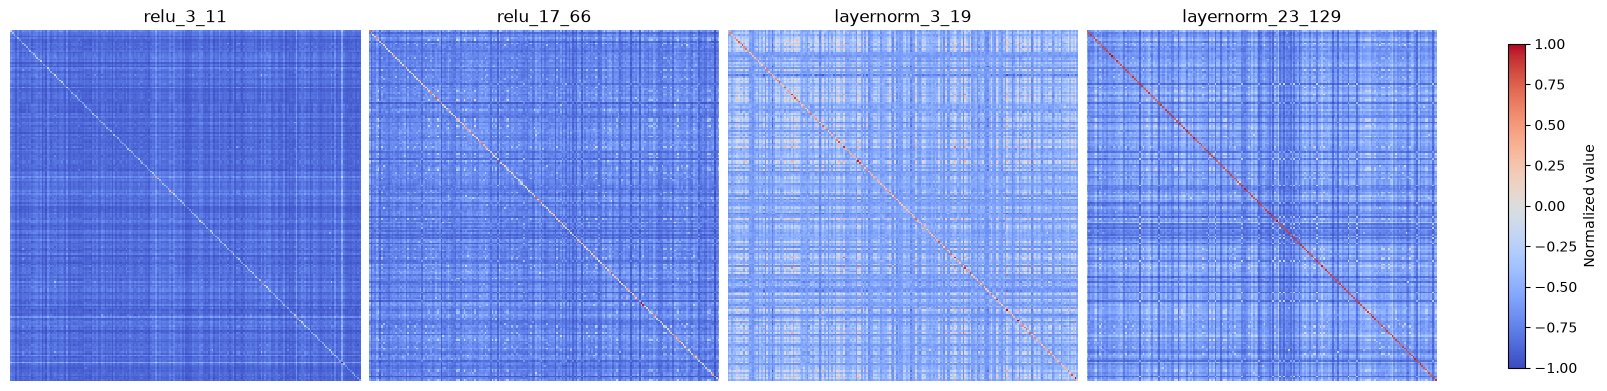

In [9]:
names = [
    "relu_3_11",
    "relu_17_66",
    "layernorm_3_19",
    "layernorm_23_129",
]
selected_covs = [all_covs[0], all_covs[7], all_covs[8], all_covs[18]]

display_normalized_covs(selected_covs=selected_covs,layers_names=names)

### 3.1.2 Computing the distances between the layers with `measure_dist`

We compute the KL divergence and JSD from BayesCompare and compare their results to the outputs of RSA and CKA. We can compute all these distances/similarities using `measure_dist` function.

For JSD and TVD we can specify the number of samples they will be computed with. The higher the samples used, the more stable and accurate the results are. However, it comes with the cost of time i.e. it takes longer with higher number of samples to compute. For reproducable results, we also can give a seeded generator to these distances.

For the RSA variant, we choose to compute RDMs with Euclidean distance and compared the RDMs with a Spearman rank correlation and for the CKA variant, we use linear CKA.

For our BayesCompare methods (JSD and KL divergence), we will use additive noise level of $\sigma^2_{\epsilon}=0.98$ (equivalently $b=0.05$). 

By default, `measure_dist` applies **trace normalization** to covariance matrices such that their trace is equal to the number of images used for obtaining the covariances. Hence, we do not need to specify this parameter for our BayesCompare methods, and also for RSA and CKA as they are invariant to **trace normalization**. But for other metrics, **trace normalization** parameter may be important and may affect the obtained distance results.

> **Note:** It is possible to supress the display of progress for the distance computations by setting `show_progress=False`.

In [10]:
print("Computing BayesCompare Measures: ")
print("KL Divergence")
KL_divs = measure_dist(all_covs, meas_name="kldiv", b=0.05)
print("Jensen-Shannon Distance")
JSD_dists = measure_dist(all_covs, meas_name="jsd", b=0.05, samples_jsd_tvd=5000, generator=torch_gen)

print("\n--------------------")

print("\nComputing Existing Measures: ")
print("Representational Similarity Analysis (RSA)")
RSA_sim = measure_dist(all_covs, meas_name="rsarank")
print("Centered Kernel Alignment (CKA)")
CKA_sim = measure_dist(all_covs, meas_name="cka")

print("\n")
dist_dict={"KL Divergence": KL_divs, "Jensen-Shannon Distance": JSD_dists, "RSA": RSA_sim, "CKA": CKA_sim}
for name, dist_mtx in dist_dict.items():
    print(f"{name:30s}  shape: {tuple(dist_mtx.shape)}")

Computing BayesCompare Measures: 
KL Divergence


100%|██████████| 171/171 [00:00<00:00, 1732.56it/s]


Jensen-Shannon Distance


100%|██████████| 171/171 [00:08<00:00, 21.21it/s]



--------------------

Computing Existing Measures: 
Representational Similarity Analysis (RSA)


100%|██████████| 171/171 [00:00<00:00, 238.12it/s]


Centered Kernel Alignment (CKA)


100%|██████████| 171/171 [00:00<00:00, 2386.24it/s]



KL Divergence                   shape: (19, 19)
Jensen-Shannon Distance         shape: (19, 19)
RSA                             shape: (19, 19)
CKA                             shape: (19, 19)


We can now display the distances between the representations of our layers, estimated by different measures. For comparible results, we are converting the similarity values of RSA and CKA into distances by simply computing (1 - RSA) or (1 - CKA).

As expected, for all measures, ResNet and ViT layers form two clusters and are distringuisable from each other.

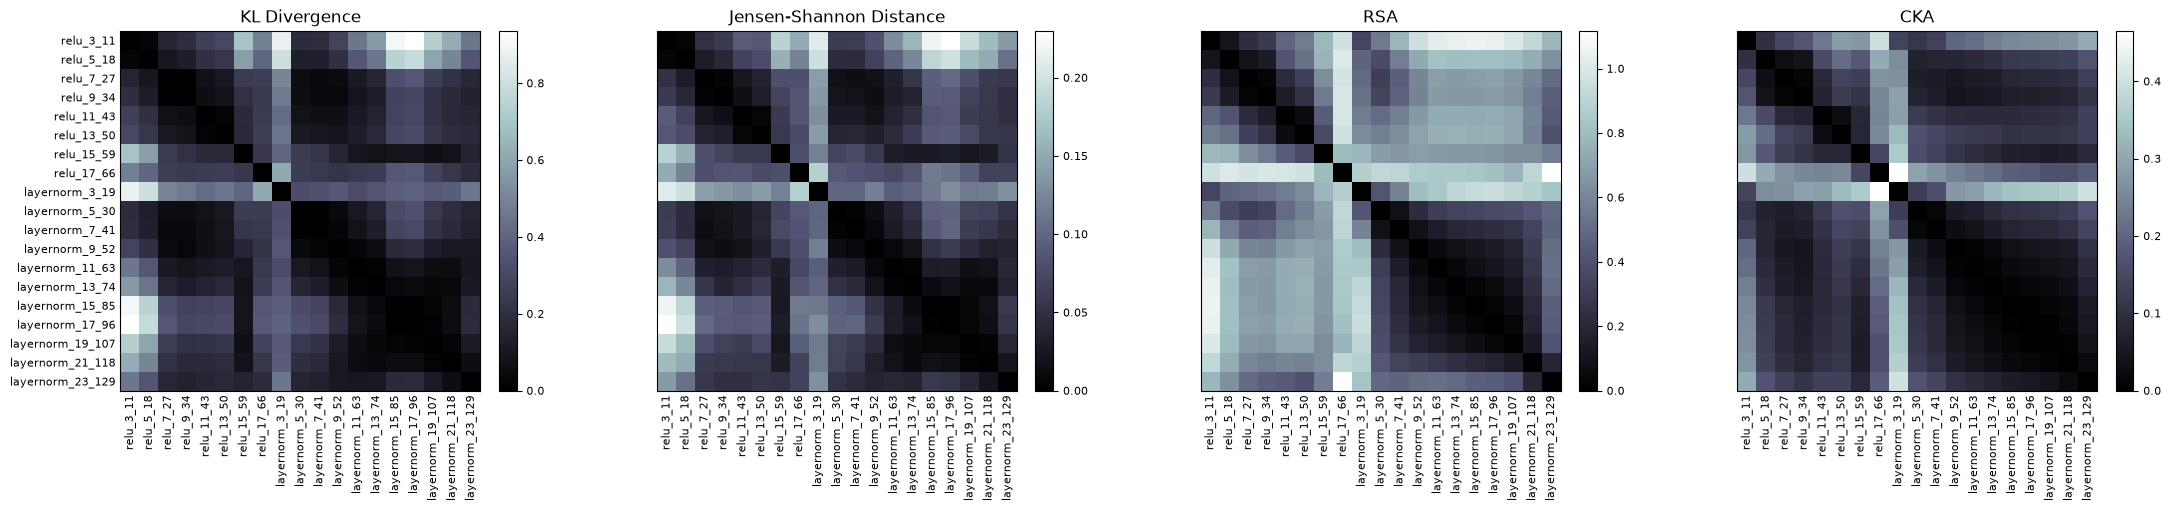

In [11]:
display_distance_matrices(dist_dict=dist_dict, layer_list=all_layer_names)

## 3.2 `measure_dist_parallel` Sections

### 3.2.1 Saving computed covariances

As shown in `cov_extractor_tutorial` of `BayesCompare`, we can use `cov_extractor_batch` to compute and directly save covariance files, or we can use `cov_extractor` function to have covariance matrices in memory and then save them. For convenience (since we already have the computed covariances in-memory) we will apply the latter, but for the usage of `cov_extractor_batch` please see the `cov_extractor_tutorial`.

In [12]:
# first, define the directory where the covariance matrix file will be saved
OUT_DIR = "./tutorial_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
cov_filename = os.path.join(OUT_DIR, "measure_distance_tutorial_covariances.npy")

# then, save all the covariances to a file. `measure_dist_parallel` function accepts .pkl and .npy files.
np.save(cov_filename, all_covs)

### 3.2.2 Computing the distances between the layers with `measure_dist_parallel`

Similar to `measure_dist` part, we will compute KL divergence, JSD, RSA and CKA. A nice feature of `measure_dist_parallel` is that we can provide it with the list of measures we wish to compute, instead of calling the function for each metric.

In [13]:
measure_dist_parallel(covs_dir=cov_filename, output_dir=OUT_DIR, meas_name=["kldiv", "jsd", "rsarank", "cka"], b=[0.05, 0.05, 0.0, 0.0], samples_jsd_tvd=5000, generator=rng)

Now computing kldiv


100%|██████████| 171/171 [00:05<00:00, 30.44it/s] 


Now computing jsd


100%|██████████| 171/171 [00:01<00:00, 92.07it/s] 


Now computing rsarank


100%|██████████| 171/171 [00:00<00:00, 1150.09it/s]


Now computing cka


100%|██████████| 171/171 [00:00<00:00, 1577.36it/s]


As convention, the output HDF5 files that have the distances are named `"dist_" + covariance_filename + _ + distance_name`. We can directly load these from the `OUT_DIR` and then display as we did for the `measure_dist`.

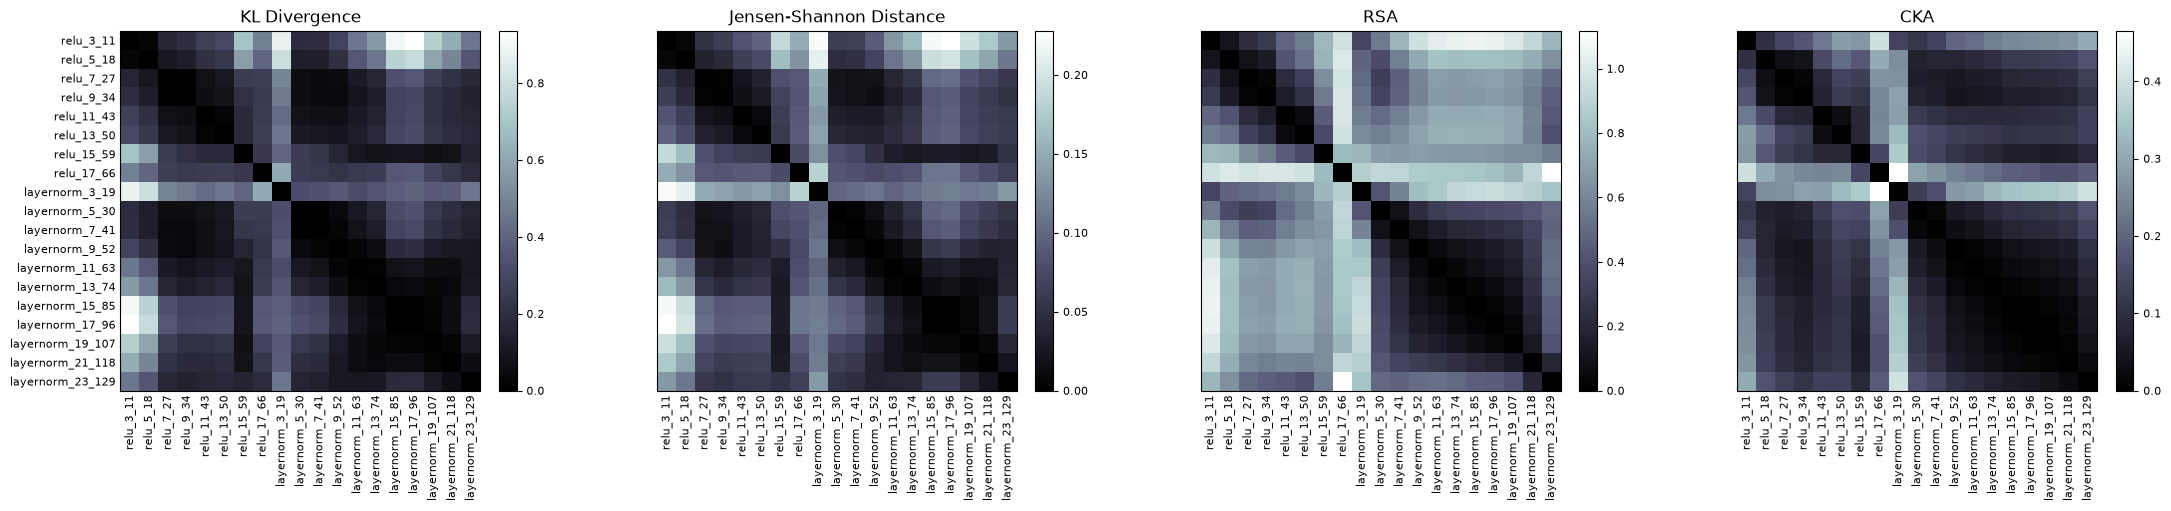

In [14]:
distance_names = ["kldiv", "jsd", "rsarank", "cka"]
corrected_dist_names = ["KL Divergence", "Jensen-Shannon Distance", "RSA", "CKA"]
hdf_filenames = [os.path.join(OUT_DIR, f"dist_measure_distance_tutorial_covariances_{dist_name}.hdf5") for dist_name in distance_names]
parallel_dists_dict = {}

for dist_idx, hdf_filename in enumerate(hdf_filenames): 
    with h5py.File(hdf_filename, "r") as f:
        dist = f["dist"][...]
    parallel_dists_dict[corrected_dist_names[dist_idx]] = dist

display_distance_matrices(dist_dict=parallel_dists_dict, layer_list=all_layer_names)

#### Consistency check: `measure_dist` vs `measure_dist_parallel`

In [15]:
print(f"{'Distance':30s}  {'Realtive diff':>15s}  {'Match?':>8s}")
print("-" * 60)
for name in ["KL Divergence", "Jensen-Shannon Distance", "RSA", "CKA"]:
    diff = np.max(np.abs(dist_dict[name].numpy() - parallel_dists_dict[name]))
    max_value_in_dists = np.max([np.max(dist_dict[name].numpy()), np.max(parallel_dists_dict[name])])
    relative_diff = diff/max_value_in_dists
    match = "✓" if relative_diff < 1e-4 else "✗"
    print(f"{name:30s}  {relative_diff:15.2e}  {match:>8s}")

Distance                          Realtive diff    Match?
------------------------------------------------------------
KL Divergence                          9.17e-06         ✓
Jensen-Shannon Distance                6.79e-02         ✗
RSA                                    2.94e-07         ✓
CKA                                    2.98e-07         ✓


As expected, the distance matrices obtained with `measure_dist` and `measure_dist_parallel` are identical, except for JSD. As JSD is not computed deterministically, and since we used a small number of samples to compute it, the difference between in-memory and parallel computation is higher.

## Summary

Here is a small summary of all the distances in `BayesCompare` and existing methods in the literature that can be computed with `measure_dist` and `measure_dist_parallel` with their respective parameters.

The `meas_name` parameter selects the distance/divergence. The table below summarises the available options:
> **Note:** `meas_name` is case insensitive and insensitive to spaces, dashes or underscores.

### BayesCompare metrics
| Full name | Deterministic? |  True metric? | Extra param | Acceptable inputs to `meas_name`|  
|---|---|---|---|---|
| Total Variation Distance | ✗ (MC) | ✓ | `samples_jsd_tvd` and `generator`| `"tvd"` `"totalvariation"` `"totalvariationdistance"`| 
| Jensen–Shannon Divergence | ✗ (MC) | ✓ | `samples_jsd_tvd` and `generator` | `"jsd"` `"jensenshannon"` `"jensenshannondivergence"` `"jensenshannondistance"`| 
| 2-Wasserstein | ✓ | ✓ | - | `"wasserstein"` | 
| Hellinger | ✓ | ✓ | - | `"hellinger"` | 
| symmetrized KL Divergence | ✓ | ✗ (semimetric) | - |`"kldiv"` `"kldivergence"`| 
| Bhattacharyya | ✓ | ✗ (semimetric) | - |`"bhattacharyya"`| 
----------------------------------------------------------
### Existing methods
| Full name | Deterministic? |  True metric? | Extra param | Acceptable inputs to `meas_name`|  
|---|---|---|---|---|
| linear Centered Kernel Alignment (CKA) | ✓ | ✗ (1-CKA is semimetric in normalized Gram matrices) | - | `"cka"` |
| Distance Correlation | ✓ | ✗ | - | `"distcorr"` `"distancecorrelation"`|
| Normalized Bures Similarity (NBS) | ✓ | ✗ | - | `"normalized_bures_similarity"` `"normalizedburessimilarity"` `"normburessim"` `"nbs"`|
| kernel GULP distance | ✓ |  ✗ (pseudometric) | `lmbd` | `"gulp"` |
| Jaccard similarity (via kNN) | ✓ | ✓ (1-Jaccard) | `k` | `"jaccard"`|

<br><br>
There are a couple of variations of RSA implemented in `BayesCompare`:

| Full name | Deterministic? |  True metric? | RDM Computation | Similarity Computation | Acceptable inputs to `meas_name`|  
|---|---|---|---|---|---|
| Representational Similarity Analysis (RSA) | ✓ | ✗ (pseudometric) | Euclidean Distances | Arccosine similarity | `"rsa_arccos"` |
| Representational Similarity Analysis (RSA) | ✓ | ✗ | Euclidean Distances | Cosine similarity | `"rsa_cos"` |
| Representational Similarity Analysis (RSA) | ✓ | ✗ | Euclidean Distances | Correlation | `"rsa_corr"` |
| Representational Similarity Analysis (RSA) | ✓ | ✗ | Euclidean Distances | Spearman's rank correlation ($\rho_a$) | `"rsa_rank"` |